In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
data = pd.read_csv('cleaned.csv')

In [2]:
data.shape

(3803, 23)

In [3]:
data.duplicated().sum()

np.int64(126)

In [4]:
data.drop_duplicates(inplace=True)

<Axes: xlabel='property_type'>

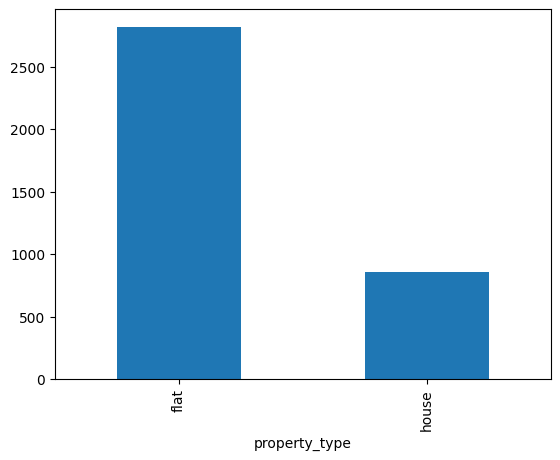

In [5]:
data['property_type'].value_counts().plot(kind='bar')

# observation

flat  = 75%
house = 25%

In [6]:
data['luxury_score'] =data['luxury_score'].fillna(0)

Society


In [7]:
data['society'].value_counts().shape
# so we have 670 different categories

(676,)

In [8]:
data['society'].value_counts()

society
independent                               486
tulip violet                               75
ss the leaf                                73
shapoorji pallonji joyville gurugram       42
dlf new town heights                       42
                                         ... 
swarn jayanti cghs                          1
shyam apartment                             1
shree vardhman mantra                       1
huda sector-56 gurgaon                      1
surendra homes dayaindependentd colony      1
Name: count, Length: 676, dtype: int64

In [9]:
data[data['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)
#if we only take 75 categories we will cover 50% of our data

society
tulip violet                            0.023511
ss the leaf                             0.046395
shapoorji pallonji joyville gurugram    0.059561
dlf new town heights                    0.072727
signature global park                   0.083699
                                          ...   
ansal heights 86                        0.490282
the close north                         0.494357
puri emerald bay                        0.498433
ireo the corridors                      0.502194
unitech uniworld resorts                0.505956
Name: proportion, Length: 75, dtype: float64

In [10]:
society_counts = data['society'].value_counts()

#frequency distribution for societies
frequency_bins ={
    "very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    'very low (1)': (society_counts == 1).sum()
}
frequency_bins

{'very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(273),
 'very low (1)': np.int64(308)}

<Axes: xlabel='society'>

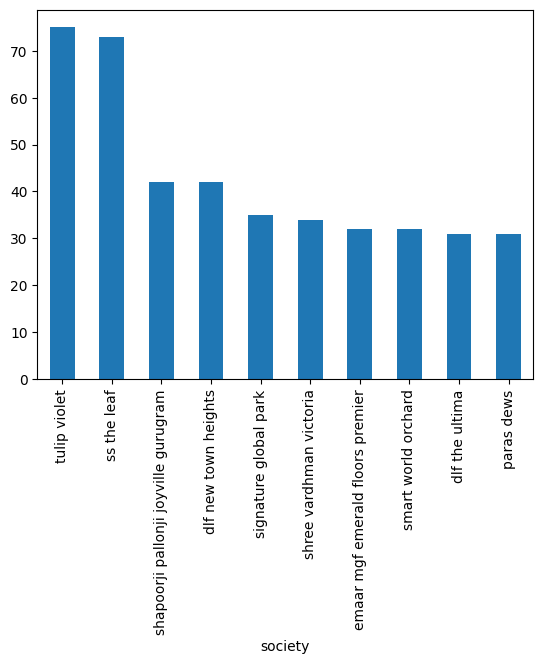

In [11]:
data[data['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [70]:
data[data['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2693,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,0,0


## Observations
Around 13% properties comes under independent tag.
There are 675 societies.
The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
Very High (>100): Only 1 society has more than 100 listings.
High (50-100): 2 societies have between 50 to 100 listings.
Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
Low (2-9): 273 societies have between 2 to 9 listings.
Very Low (1): A significant number, 308 societies, have only 1 listing.
1 missing value

sector

In [13]:
data['sector'].value_counts().shape

(104,)

<Axes: xlabel='sector'>

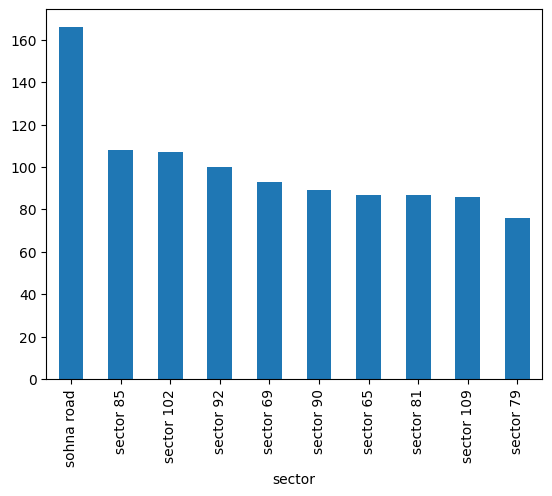

In [14]:
data['sector'].value_counts().head(10).plot(kind='bar')

In [15]:
sector_counts =data['sector'].value_counts()
sector_bins = {
    "very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    'very low (1)': (sector_counts == 1).sum()
}
sector_bins 

{'very High (>100)': np.int64(3),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(60),
 'Low (2-9)': np.int64(16),
 'very low (1)': np.int64(0)}

## Observations
There are a total of 104 unique sectors in the dataset.
Frequency distribution of sectors:
Very High (>100): 3 sectors have more than 100 listings.
High (50-100): 25 sectors have between 50 to 100 listings.
Average (10-49): A majority, 60 sectors, fall in this range with 10 to 49 listings each.
Low (2-9): 16 sectors have between 2 to 9 listings.
Very Low (1): Interestingly, there are no sectors with only 1 listing.

Price

In [16]:
data['price'].isnull().sum()

np.int64(17)

In [17]:
data['price'].describe()

count    3660.000000
mean        2.533664
std         2.980623
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

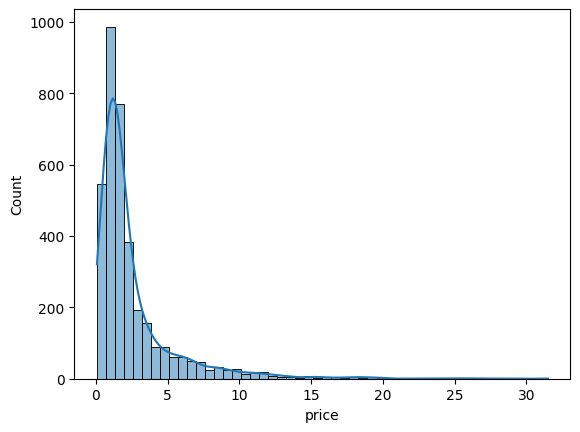

In [18]:
sns.histplot(data['price'], bins=50, kde=True)

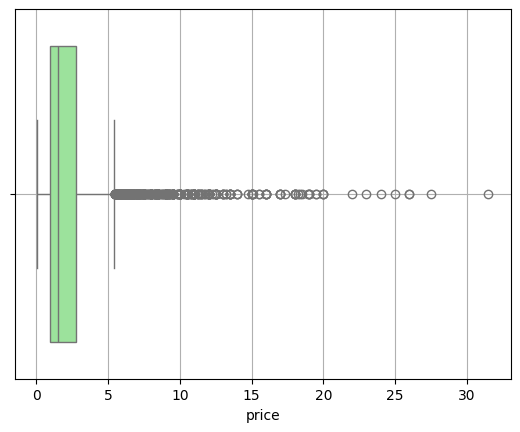

In [19]:
sns.boxplot(x=data['price'],color='lightgreen')
plt.grid()

# Descriptive Statistics:

Count: There are 3,660 non-missing price entries.
Mean Price: The average price is approximately 2.53 crores.
Median Price: The median (or 50th percentile) price is 1.52 crores.
Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.
Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.
# Visualizations:

Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.
Missing Values: There are 17 missing values in the price column.

In [20]:
skewness = data['price'].skew()
kurtosis = data['price'].kurt()
print(skewness,kurtosis)

3.2791704733134623 14.933372629214258


distribution has a skewness of 3.28 aprox,means popsitive skew , distribution tail is skewed to right
kurtosis value is 14.93 greater than 3 means heavier tails and more outliers compared to normal distribution.

In [21]:
quantiles = data['price'].quantile([0.01,0.05,0.95,0.99])
quantiles

0.01     0.250
0.05     0.370
0.95     8.500
0.99    15.264
Name: price, dtype: float64

0.01 properties are below 0.25 
0.05 properties are below 0.370
0.95 properties are below 8.500
0.99 properties are below 15.264

In [22]:
q1 = data['price'].describe()['25%']
q3 = data['price'].describe()['75%']
iqr = q3-q1
iqr

np.float64(1.8)

In [23]:
lower_bound = q1- 1.5*iqr
upper_bound = q3 + 1.5*iqr

print(lower_bound,upper_bound)


-1.7500000000000002 5.45


In [24]:
outliers = data[(data['price'] < lower_bound) | (data['price'] > upper_bound)]
outliers.shape

(425, 23)

In [25]:
outliers['price'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

based on iqr method , there are 425 properties considered outliers
these outliers have average price of approximately 9.24 crores
the range is between 5.46 cr to 31.5 cr

<Axes: xlabel='price'>

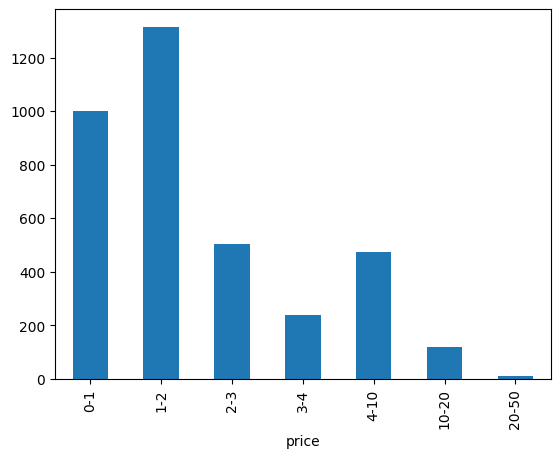

In [26]:
#price binning
bins = [0,1,2,3,4,10,20,50]
labels = ['0-1','1-2','2-3','3-4','4-10','10-20','20-50']
pd.cut(data['price'], bins=bins, labels=labels,right=False).value_counts().sort_index().plot(kind='bar')


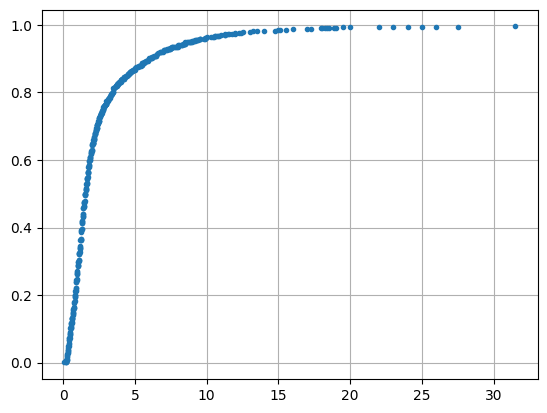

In [27]:
ecdata = data['price'].value_counts().sort_index().cumsum() / len(data)
plt.plot(ecdata.index, ecdata,marker='.', linestyle='none')
plt.grid()

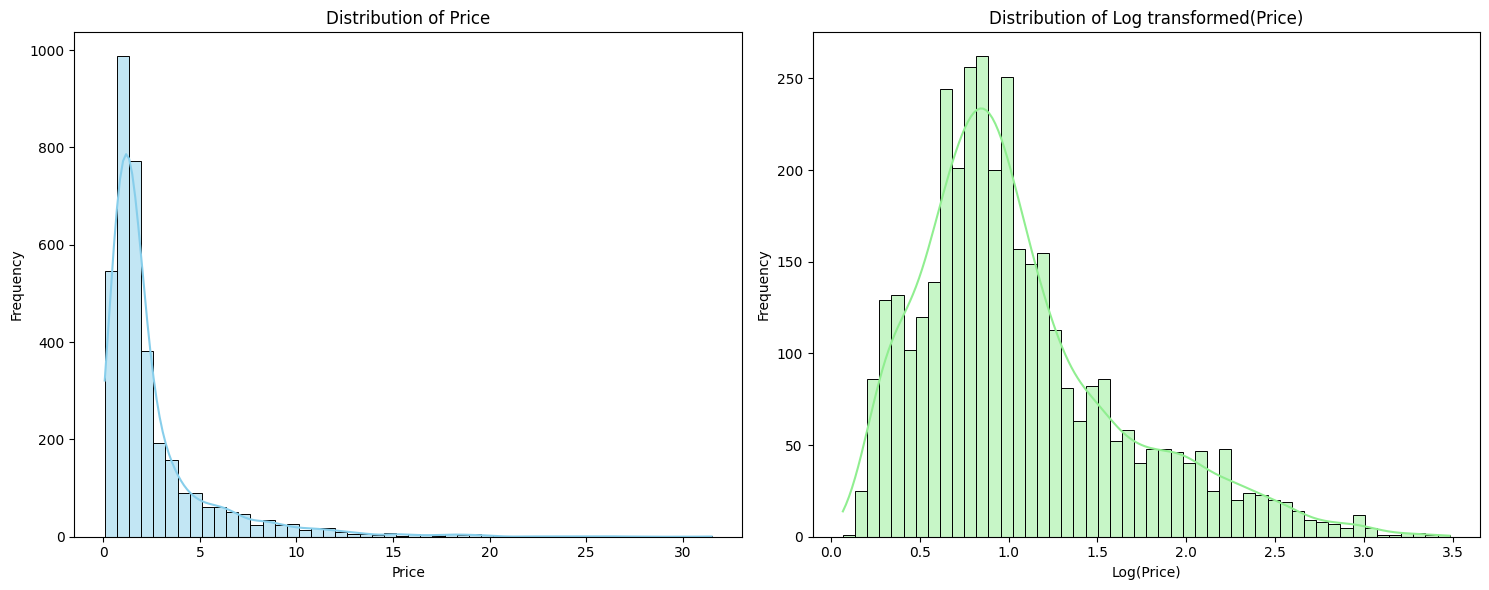

In [28]:
import numpy as np
plt.figure(figsize=(15,6))

#distribution plot without log transformation
plt.subplot(1,2,1)
sns.histplot(data['price'], bins=50, kde=True,color ='skyblue')
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')

#distribution plot with log transformation
plt.subplot(1,2,2)
sns.histplot(np.log1p(data['price']), bins=50, kde=True, color='lightgreen')
plt.title('Distribution of Log transformed(Price)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency') 

plt.tight_layout()
plt.show()

In [29]:
skewness = np.log1p(data['price']).skew()
kurtosis = np.log1p(data['price']).kurt()
print(skewness,kurtosis)

1.0740709565255315 0.9646692415449296


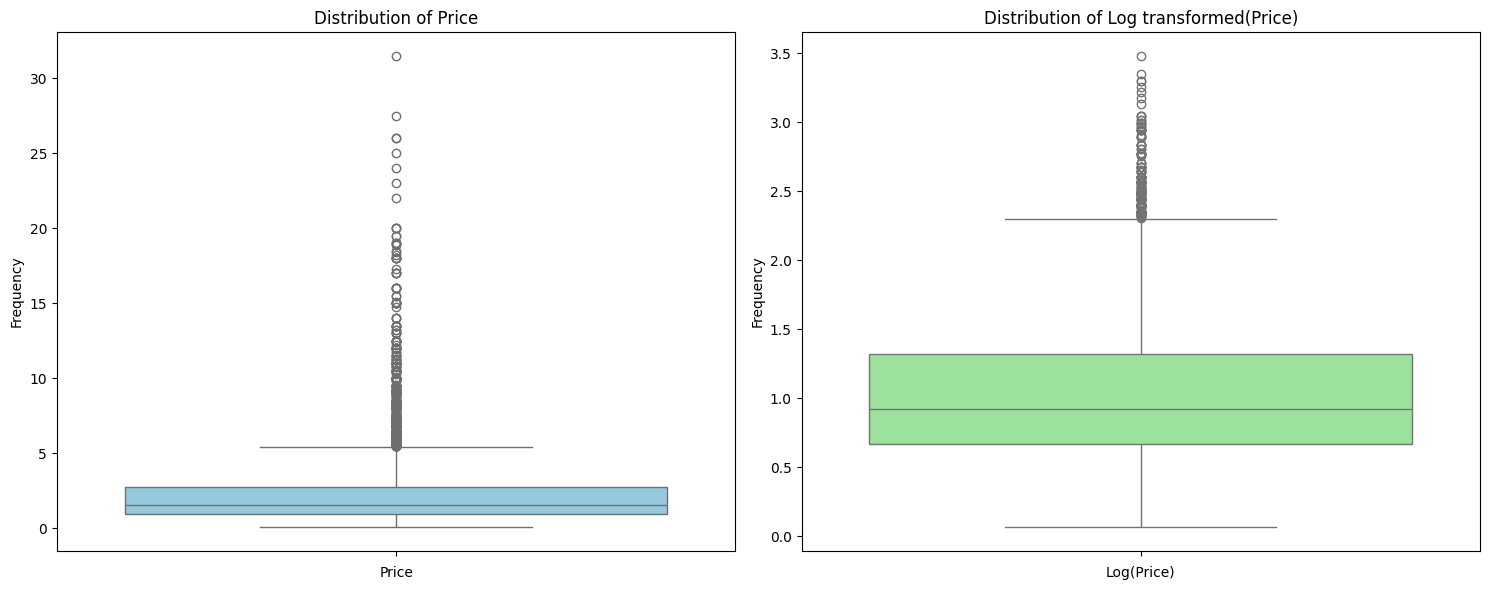

In [30]:
import numpy as np
plt.figure(figsize=(15,6))

#distribution plot without log transformation
plt.subplot(1,2,1)
sns.boxplot(data['price'],color ='skyblue')
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')

#distribution plot with log transformation
plt.subplot(1,2,2)
sns.boxplot(np.log1p(data['price']), color='lightgreen')
plt.title('Distribution of Log transformed(Price)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency') 

plt.tight_layout()
plt.show()

price_per_sqft

In [31]:
data['price_per_sqft'].isnull().sum()

np.int64(17)

In [32]:
data['price_per_sqft'].describe()

count      3660.000000
mean      13892.668306
std       23210.067190
min           4.000000
25%        6817.250000
50%        9020.000000
75%       13880.500000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

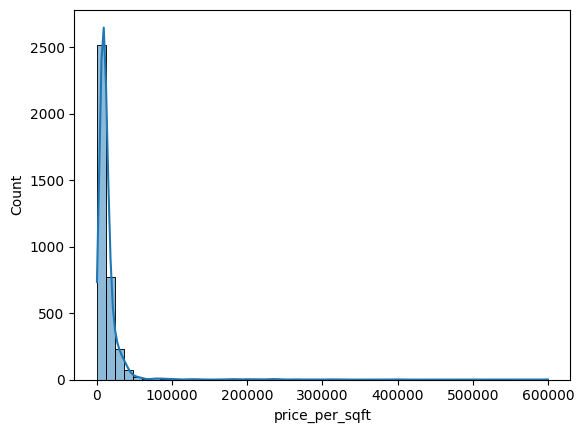

In [33]:
sns.histplot(data['price_per_sqft'], bins=50, kde=True)

<Axes: ylabel='price_per_sqft'>

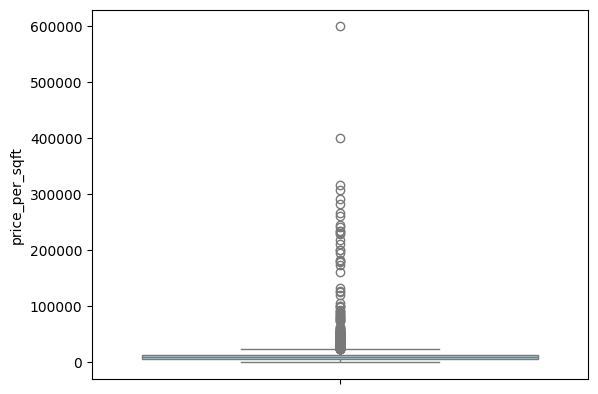

In [34]:
sns.boxplot(data['price_per_sqft'],color='lightblue')

bedroom

<Axes: xlabel='bedRoom'>

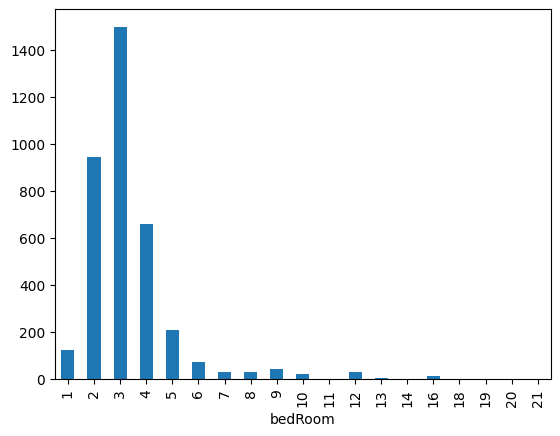

In [35]:
data['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: >

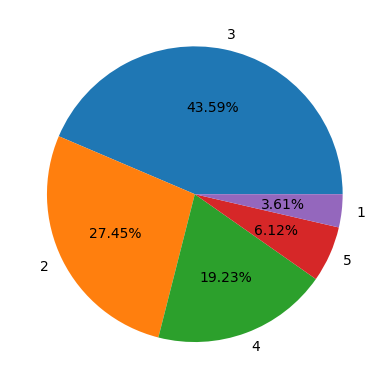

In [36]:
data['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

bathroom

<Axes: xlabel='bathroom'>

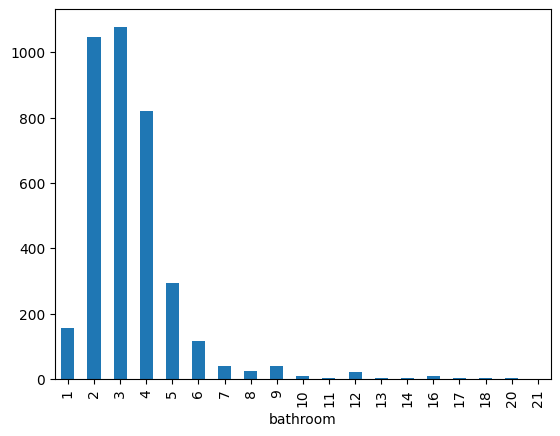

In [37]:
data['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: >

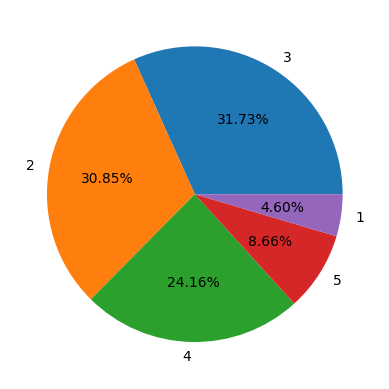

In [38]:
data['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

balcony

<Axes: xlabel='balcony'>

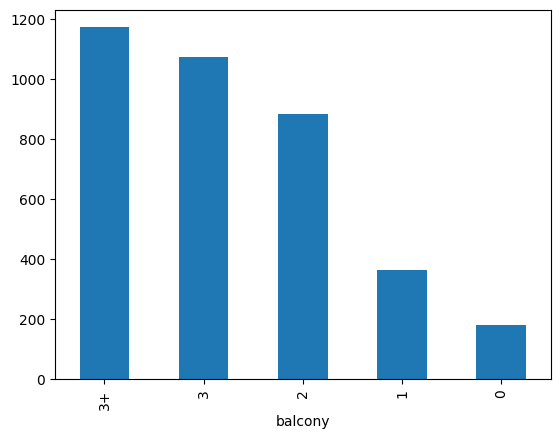

In [39]:
data['balcony'].value_counts().plot(kind='bar')

<Axes: >

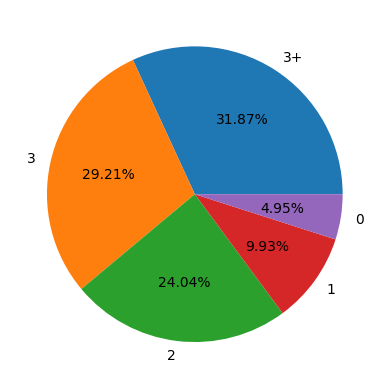

In [40]:
data['balcony'].value_counts().head().plot(kind='pie',autopct='%0.2f%%')   

floornum

In [41]:
data['floorNum'].isnull().sum()

np.int64(19)

In [42]:
data['floorNum'].describe()

count    3658.000000
mean        6.798250
std         6.012454
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

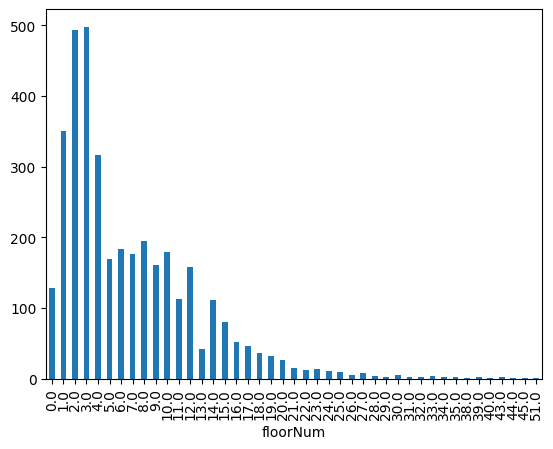

In [43]:
data['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

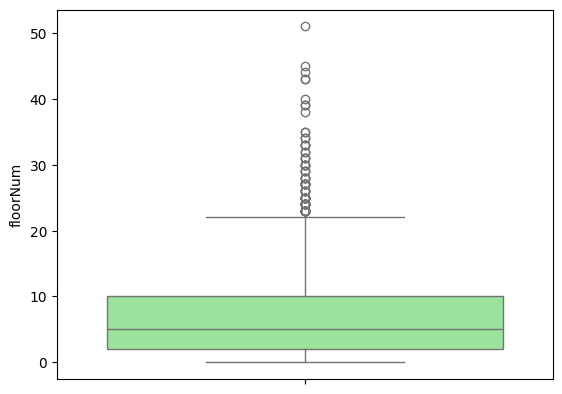

In [44]:
sns.boxplot(data['floorNum'],color='lightgreen')

facing


In [45]:
data['facing'].isnull().sum()

np.int64(1045)

In [46]:
data['facing']=data['facing'].fillna('NA')


In [47]:
data['facing'].value_counts()

facing
NA            1045
North-East     623
East           623
North          387
West           249
South          231
North-West     193
South-East     173
South-West     153
Name: count, dtype: int64

agepossession

In [48]:
data['agePossession'].isnull().sum()

np.int64(0)

In [49]:
data['agePossession'].value_counts()

agePossession
Relatively New        1646
New Property           593
Moderately Old         563
Undefined              306
Old Property           303
Under Construction     266
Name: count, dtype: int64

area 

In [50]:
data['super_built_up_area'].isnull().sum()

np.int64(1802)

In [51]:
data['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

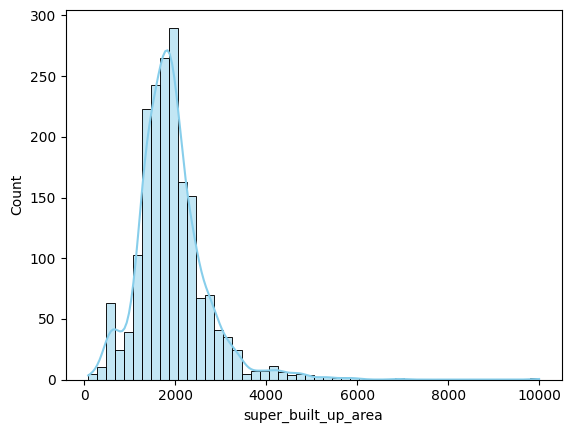

In [52]:
sns.histplot(data['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

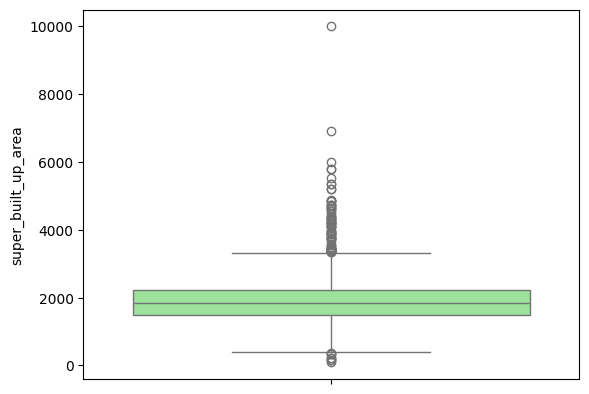

In [53]:
sns.boxplot(data['super_built_up_area'].dropna(), color='lightgreen')

Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
There are a few properties with a significantly larger area, leading to a right-skewed distribution.
The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [54]:
# built up area
data['built_up_area'].isnull().sum()

np.int64(1987)

In [55]:
data['built_up_area'].describe()

count      1690.000000
mean       2379.585816
std       17942.880237
min           2.000000
25%        1100.000000
50%        1650.000000
75%        2400.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

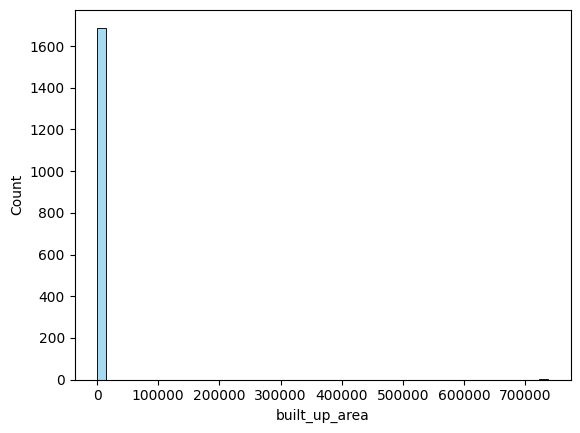

In [56]:
sns.histplot(data['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

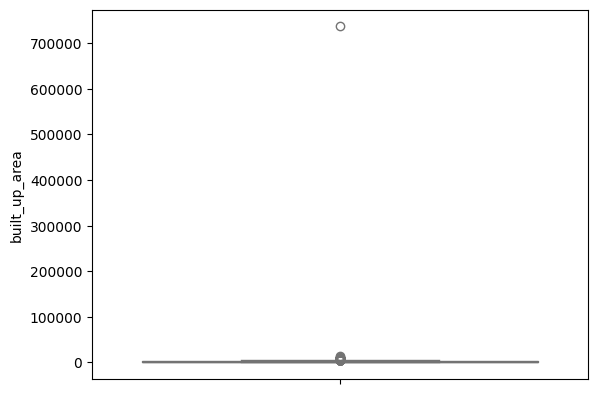

In [57]:
sns.boxplot(data['built_up_area'].dropna(), color='lightgreen')

Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.
The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

In [58]:
# carpet area
data['carpet_area'].isnull().sum()

np.int64(1805)

In [59]:
data['carpet_area'].describe()

count      1872.000000
mean       2529.179507
std       22799.836449
min          15.000000
25%         843.000000
50%        1300.000000
75%        1790.000000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

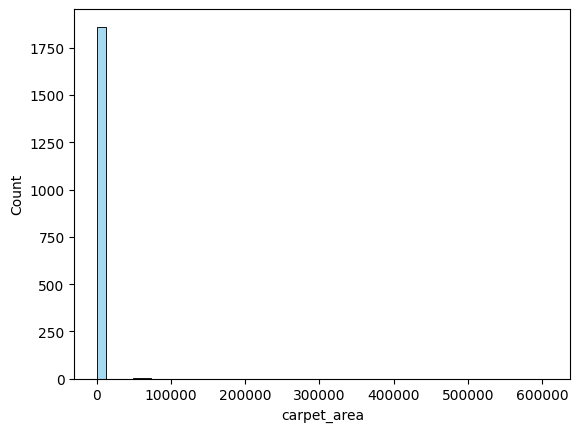

In [60]:
sns.histplot(data['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='carpet_area'>

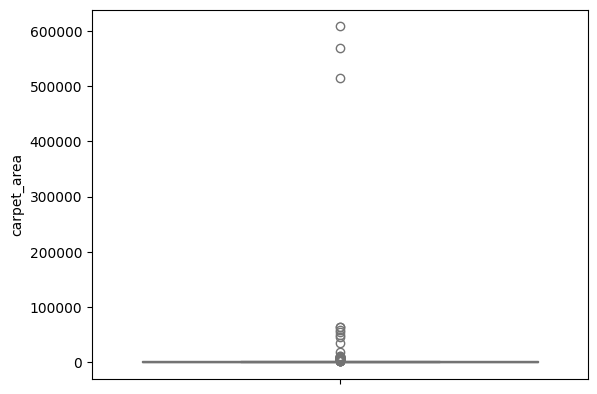

In [61]:
sns.boxplot(data['carpet_area'].dropna(), color='lightgreen')

In [62]:
data.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,0,0,0,0,0,8
1,1,1,0,0,0,0,38
2,0,0,0,0,0,0,15
3,0,0,0,0,0,0,49
4,0,1,0,0,1,1,174
...,...,...,...,...,...,...,...
3798,0,0,0,0,0,0,73
3799,1,1,1,1,0,0,160
3800,0,0,0,0,0,1,67
3801,1,1,1,1,0,0,76


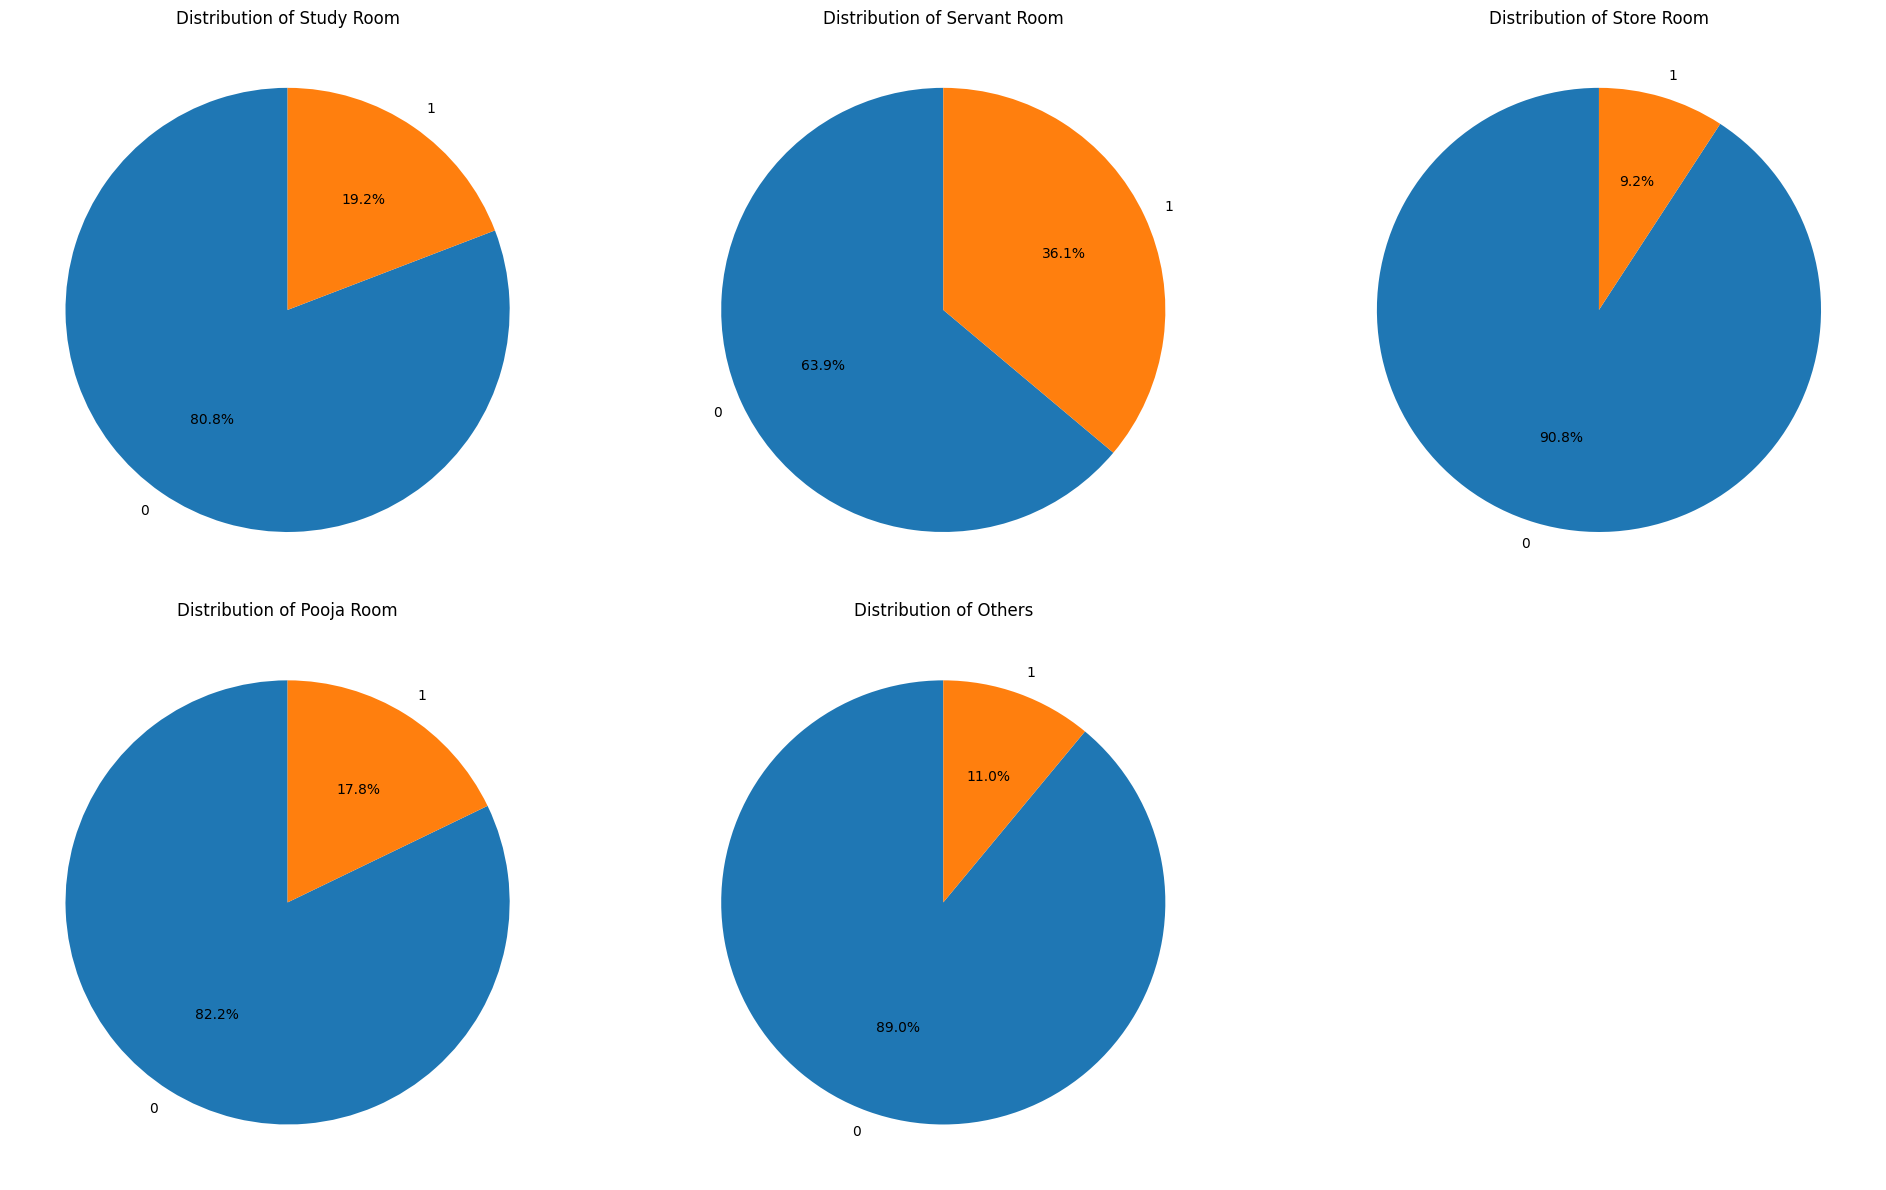

In [63]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    data[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [64]:
data['furnishing_type'].value_counts()

furnishing_type
0    2411
1    1059
2     207
Name: count, dtype: int64

<Axes: >

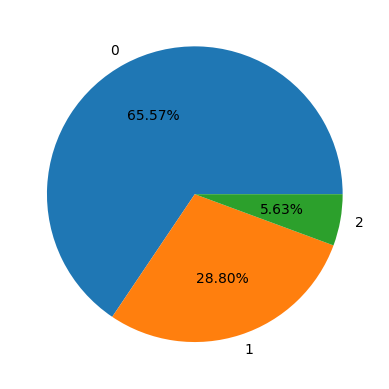

In [65]:
data['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

luxury score

In [66]:
data['luxury_score'].isnull().sum()

np.int64(0)

In [67]:
data['luxury_score'].describe()

count    3677.000000
mean       71.512918
std        53.059082
min         0.000000
25%        31.000000
50%        59.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

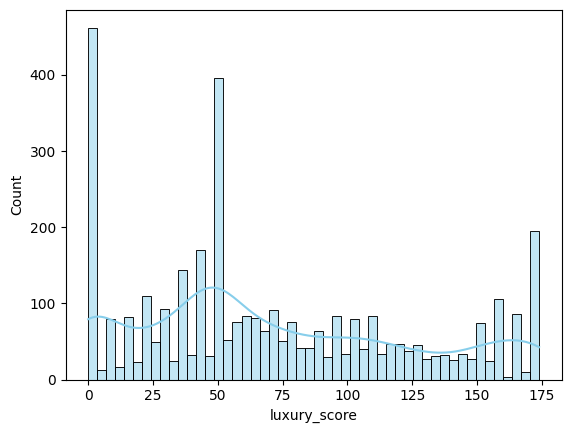

In [68]:
sns.histplot(data['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

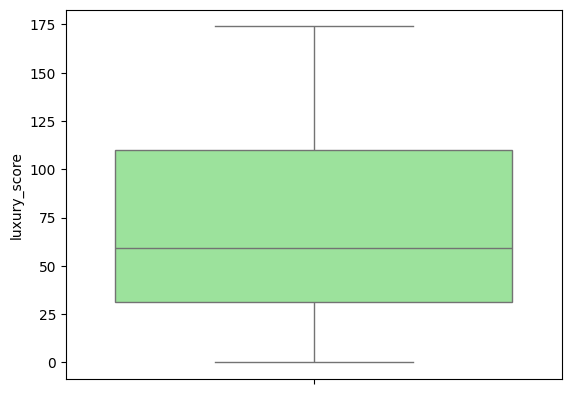

In [69]:
sns.boxplot(data['luxury_score'], color='lightgreen')

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.